### Sales Forecasting — Phase 3: XGBoost with Lag & Calendar Features
### Rossmann Store Sales Dataset
 
Steps:
  1. Load cleaned data from Phase 1
  2. Feature engineering — lag, rolling, calendar, store features
  3. Time-aware train/test split
  4. XGBoost training + cross-validation
  5. Evaluation — MAPE, RMSE, MAE
  6. Feature importance plot
  7. Forecast visualisation
  8. Save predictions for Phase 4 comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "grid.linewidth": 0.6})

STORE_ID   = 1       # keep same store as Phase 2 for fair comparison
TEST_WEEKS = 6       # same held-out period as Phase 2
SEED       = 42

c:\Users\Tammy\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\Tammy\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### LOAD DATA

In [2]:
df = pd.read_csv("rossmann_clean.csv", parse_dates=["Date"],
                 low_memory=False)
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
 
print("=" * 60)
print("PHASE 3 — XGBoost with Lag & Calendar Features")
print("=" * 60)
print(f"Full dataset : {len(df):,} rows, {df['Store'].nunique()} stores")

PHASE 3 — XGBoost with Lag & Calendar Features
Full dataset : 844,338 rows, 1115 stores


### FEATURE ENGINEERING

In [5]:
#    This is where XGBoost's advantage over ARIMA is built.
#    ARIMA only uses the series' own history.
#    XGBoost can use lag values + external signals like promos and holidays.

 
def make_features(df):
    df = df.copy()

    # Fill Promo2 columns — NaN means store never ran Promo2, not missing data
    for col in ["Promo2SinceWeek", "Promo2SinceYear", "PromoInterval"]:
       if col in df.columns:
          df[col] = df[col].fillna(0)
 
    # ── Calendar features ────────────────────────────────────────────────
    df["DayOfWeek"]   = df["Date"].dt.dayofweek        # 0=Mon, 6=Sun
    df["Month"]       = df["Date"].dt.month
    df["Year"]        = df["Date"].dt.year
    df["WeekOfYear"]  = df["Date"].dt.isocalendar().week.astype(int)
    df["DayOfMonth"]  = df["Date"].dt.day
    df["IsWeekend"]   = (df["DayOfWeek"] >= 5).astype(int)
    df["Quarter"]     = df["Date"].dt.quarter
 
    # Month-end and month-start — often see spending spikes
    df["IsMonthEnd"]   = df["Date"].dt.is_month_end.astype(int)
    df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)
 
    # ── Lag features — per store ─────────────────────────────────────────
    # CRITICAL: sort by Store then Date before creating lags
    # to prevent lag values bleeding across different stores
    for lag in [1, 2, 3, 7, 14, 21, 28, 30]:
        df[f"lag_{lag}"] = df.groupby("Store")["Sales"].shift(lag)
 
    # ── Rolling window features — per store ──────────────────────────────
    for window in [7, 14, 30]:
        df[f"rolling_mean_{window}"] = (
            df.groupby("Store")["Sales"]
            .shift(1)                          # shift 1 to avoid leakage
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
        df[f"rolling_std_{window}"] = (
            df.groupby("Store")["Sales"]
            .shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).std())
        )
        df[f"rolling_max_{window}"] = (
            df.groupby("Store")["Sales"]
            .shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).max())
        )
 
    # ── Expanding mean — cumulative average per store ────────────────────
    df["expanding_mean"] = (
        df.groupby("Store")["Sales"]
        .shift(1)
        .transform(lambda x: x.expanding().mean())
    )
 
    # ── Store features from store.csv (already merged) ───────────────────
    # StoreType, Assortment — encode as integers
    if "StoreType" in df.columns:
        df["StoreType_enc"] = df["StoreType"].map(
            {"a": 0, "b": 1, "c": 2, "d": 3}).fillna(0).astype(int)
    if "Assortment" in df.columns:
        df["Assortment_enc"] = df["Assortment"].map(
            {"a": 0, "b": 1, "c": 2}).fillna(0).astype(int)
 
    # Competition distance — log-transform, fill with large value if missing
    if "CompetitionDistance" in df.columns:
        df["LogCompetitionDistance"] = np.log1p(
            df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
        )
 
    # ── Interaction features ─────────────────────────────────────────────
    df["Promo_DayOfWeek"]   = df["Promo"] * df["DayOfWeek"]
    df["Promo_lag7"] = df["Promo"] * df["lag_7"].fillna(0)
 
    return df
 
 
print("\nEngineering features...")
df_feat = make_features(df)
 
# Drop rows with NaN from lagging (first ~30 rows per store)
df_feat = df_feat.dropna().reset_index(drop=True)

print("=== DIAGNOSTIC ===")
print("1. Original df shape:", df.shape)
print("2. Store 1 rows in original df:", (df["Store"] == 1).sum())
print("3. df_feat shape after dropna:", df_feat.shape)
print("4. Store 1 rows in df_feat:", (df_feat["Store"] == 1).sum())
print("5. Date dtype in df_feat:", df_feat["Date"].dtype)
print("6. Store dtype in df_feat:", df_feat["Store"].dtype)
print("7. Sample dates:", df_feat["Date"].head(3).tolist())
print("8. NaN count in df_feat:", df_feat.isna().sum().sum())
print("9. Unique stores in df_feat:", df_feat["Store"].nunique())
print(f"Rows after dropping NaN lags: {len(df_feat):,}")
 
# ── Feature columns ───────────────────────────────────────────────────────
LAG_COLS = [c for c in df_feat.columns if c.startswith("lag_")]
ROLL_COLS = [c for c in df_feat.columns if c.startswith("rolling_")]
CAL_COLS  = ["DayOfWeek", "Month", "Year", "WeekOfYear", "DayOfMonth",
             "IsWeekend", "Quarter", "IsMonthEnd", "IsMonthStart"]
STORE_COLS = [c for c in ["StoreType_enc", "Assortment_enc",
                           "LogCompetitionDistance", "expanding_mean"]
              if c in df_feat.columns]
PROMO_COLS = ["Promo", "Promo2", "Promo_DayOfWeek", "Promo_lag7"] \
    if "Promo2" in df_feat.columns else \
    ["Promo", "Promo_DayOfWeek", "Promo_lag7"]
PROMO_COLS = [c for c in PROMO_COLS if c in df_feat.columns]
 
FEATURE_COLS = LAG_COLS + ROLL_COLS + CAL_COLS + STORE_COLS + PROMO_COLS
 
print(f"\nFeature groups:")
print(f"  Lag features     : {len(LAG_COLS)}  {LAG_COLS}")
print(f"  Rolling features : {len(ROLL_COLS)}")
print(f"  Calendar features: {len(CAL_COLS)}")
print(f"  Store features   : {len(STORE_COLS)}")
print(f"  Promo features   : {len(PROMO_COLS)}")
print(f"  Total features   : {len(FEATURE_COLS)}")


Engineering features...
=== DIAGNOSTIC ===
1. Original df shape: (844338, 18)
2. Store 1 rows in original df: 781
3. df_feat shape after dropna: (552908, 49)
4. Store 1 rows in df_feat: 751
5. Date dtype in df_feat: datetime64[us]
6. Store dtype in df_feat: int64
7. Sample dates: [Timestamp('2013-02-06 00:00:00'), Timestamp('2013-02-07 00:00:00'), Timestamp('2013-02-08 00:00:00')]
8. NaN count in df_feat: 0
9. Unique stores in df_feat: 761
Rows after dropping NaN lags: 552,908

Feature groups:
  Lag features     : 8  ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_30']
  Rolling features : 9
  Calendar features: 9
  Store features   : 4
  Promo features   : 4
  Total features   : 34


In [4]:
store1_feat = make_features(df[df["Store"] == 1].copy())
print("Store 1 rows before dropna:", len(store1_feat))
print("Store 1 rows after dropna:", len(store1_feat.dropna()))
print("\nNaN counts per column:")
nan_cols = store1_feat.isna().sum()
print(nan_cols[nan_cols > 0].sort_values(ascending=False))

Store 1 rows before dropna: 781
Store 1 rows after dropna: 0

NaN counts per column:
Promo2SinceWeek    781
PromoInterval      781
Promo2SinceYear    781
lag_30              30
lag_28              28
lag_21              21
lag_14              14
Promo_lag7           7
lag_7                7
lag_3                3
lag_2                2
rolling_std_7        2
rolling_std_14       2
rolling_std_30       2
lag_1                1
rolling_max_7        1
rolling_mean_14      1
rolling_max_14       1
rolling_mean_30      1
rolling_max_30       1
expanding_mean       1
rolling_mean_7       1
dtype: int64


### TIME-AWARE TRAIN/TEST SPLIT — STORE 1 ONLY

In [6]:
#    Compare directly with Phase 2 ARIMA on the same store & test period
 
store_df = df_feat[df_feat["Store"] == STORE_ID].copy()
 
split_date = store_df["Date"].max() - pd.Timedelta(weeks=TEST_WEEKS)
 
train_df = store_df[store_df["Date"] <= split_date]
test_df  = store_df[store_df["Date"] >  split_date]
 
X_train = train_df[FEATURE_COLS]
y_train = train_df["Sales"]
X_test  = test_df[FEATURE_COLS]
y_test  = test_df["Sales"]
 
print(f"\nStore {STORE_ID} split:")
print(f"  Train : {len(X_train)} rows  "
      f"({train_df['Date'].min().date()} → {train_df['Date'].max().date()})")
print(f"  Test  : {len(X_test)} rows   "
      f"({test_df['Date'].min().date()} → {test_df['Date'].max().date()})")


Store 1 split:
  Train : 715 rows  (2013-02-06 → 2015-06-19)
  Test  : 36 rows   (2015-06-20 → 2015-07-31)


In [7]:
print("Original rows:", len(df))
print("Store 1 rows:", (df["Store"] == 1).sum())
print("Store IDs:", df["Store"].unique()[:10])

Original rows: 844338
Store 1 rows: 781
Store IDs: [ 1  2  3  4  5  6  7  8  9 10]


In [8]:
print("Feature rows:", len(df_feat))
print("Store 1 rows in df_feat:", (df_feat["Store"] == 1).sum())
print("NaT dates:", df_feat["Date"].isna().sum())

Feature rows: 552908
Store 1 rows in df_feat: 751
NaT dates: 0


In [9]:
missing = df_feat.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Series([], dtype: int64)


### XGBOOST — BASELINE (NO TUNING)

In [10]:
print("\n── XGBoost baseline ──────────────────────────────────")
 
xgb_base = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.05,
    max_depth       = 5,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    min_child_weight= 5,
    random_state    = SEED,
    n_jobs          = -1,
    verbosity       = 0,
)
xgb_base.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=False)
 
y_pred_base = xgb_base.predict(X_test)
y_pred_base = np.clip(y_pred_base, 0, None)   # sales can't be negative
 
 
def evaluate(actual, predicted, label):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual > 0
    mape = np.mean(np.abs((actual[mask]-predicted[mask])/actual[mask])) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"  {label:<32} MAPE={mape:.2f}%  "
          f"RMSE=€{rmse:,.0f}  MAE=€{mae:,.0f}")
    return {"label": label, "MAPE": round(mape,2),
            "RMSE": round(rmse,0), "MAE": round(mae,0)}
 
 
results = []
results.append(evaluate(y_test, y_pred_base, "XGBoost (baseline)"))


── XGBoost baseline ──────────────────────────────────
  XGBoost (baseline)               MAPE=6.37%  RMSE=€351  MAE=€281


### XGBOOST — TUNED MODEL

In [11]:
print("\n── XGBoost tuned ─────────────────────────────────────")
 
xgb_tuned = XGBRegressor(
    n_estimators     = 800,
    learning_rate    = 0.03,
    max_depth        = 6,
    subsample        = 0.75,
    colsample_bytree = 0.75,
    min_child_weight = 3,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0,
)
xgb_tuned.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
 
y_pred_tuned = np.clip(xgb_tuned.predict(X_test), 0, None)
results.append(evaluate(y_test, y_pred_tuned, "XGBoost (tuned)"))


── XGBoost tuned ─────────────────────────────────────
  XGBoost (tuned)                  MAPE=6.06%  RMSE=€332  MAE=€267


### COMPARISON TABLE

In [12]:
results_df = pd.DataFrame(results).sort_values("MAPE")
print(f"\n{'='*60}")
print("XGBOOST COMPARISON")
print(f"{'='*60}")
print(results_df.to_string(index=False))
 
best_pred  = y_pred_tuned if results_df.iloc[0]["label"] == "XGBoost (tuned)" \
             else y_pred_base
best_model = xgb_tuned if results_df.iloc[0]["label"] == "XGBoost (tuned)" \
             else xgb_base
best_mape  = results_df.iloc[0]["MAPE"]


XGBOOST COMPARISON
             label  MAPE  RMSE   MAE
   XGBoost (tuned)  6.06 332.0 267.0
XGBoost (baseline)  6.37 351.0 281.0


### FEATURE IMPORTANCE PLOT

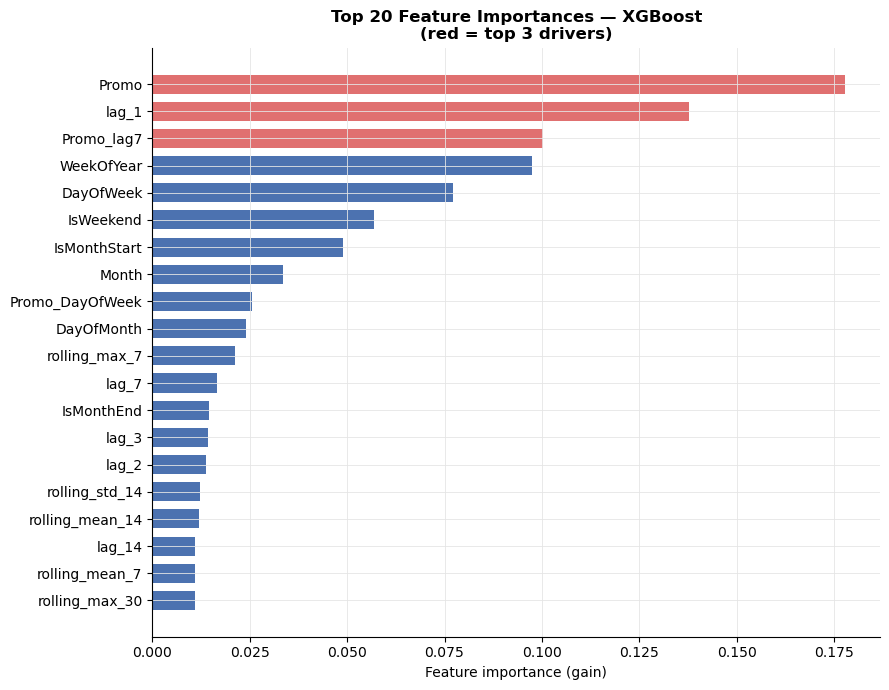


Top 10 features:
Promo              0.1779
lag_1              0.1378
Promo_lag7         0.1002
WeekOfYear         0.0975
DayOfWeek          0.0771
IsWeekend          0.0568
IsMonthStart       0.0490
Month              0.0335
Promo_DayOfWeek    0.0255
DayOfMonth         0.0240

Key insight: lag_7 (last week's sales on same day) is typically
the strongest predictor — the day-of-week pattern is very stable.


In [13]:
importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)
 
top20 = importances.head(20).sort_values()
 
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#E07070" if i >= 17 else "#4C72B0"
          for i in range(len(top20))]
ax.barh(top20.index, top20.values, color=colors, height=0.7)
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 20 Feature Importances — XGBoost\n"
             "(red = top 3 drivers)", fontweight="bold")
plt.tight_layout()
plt.savefig("phase3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
 
print(f"\nTop 10 features:")
print(importances.head(10).round(4).to_string())
print(f"\nKey insight: lag_7 (last week's sales on same day) is typically")
print(f"the strongest predictor — the day-of-week pattern is very stable.")

### FORECAST VISUALISATION

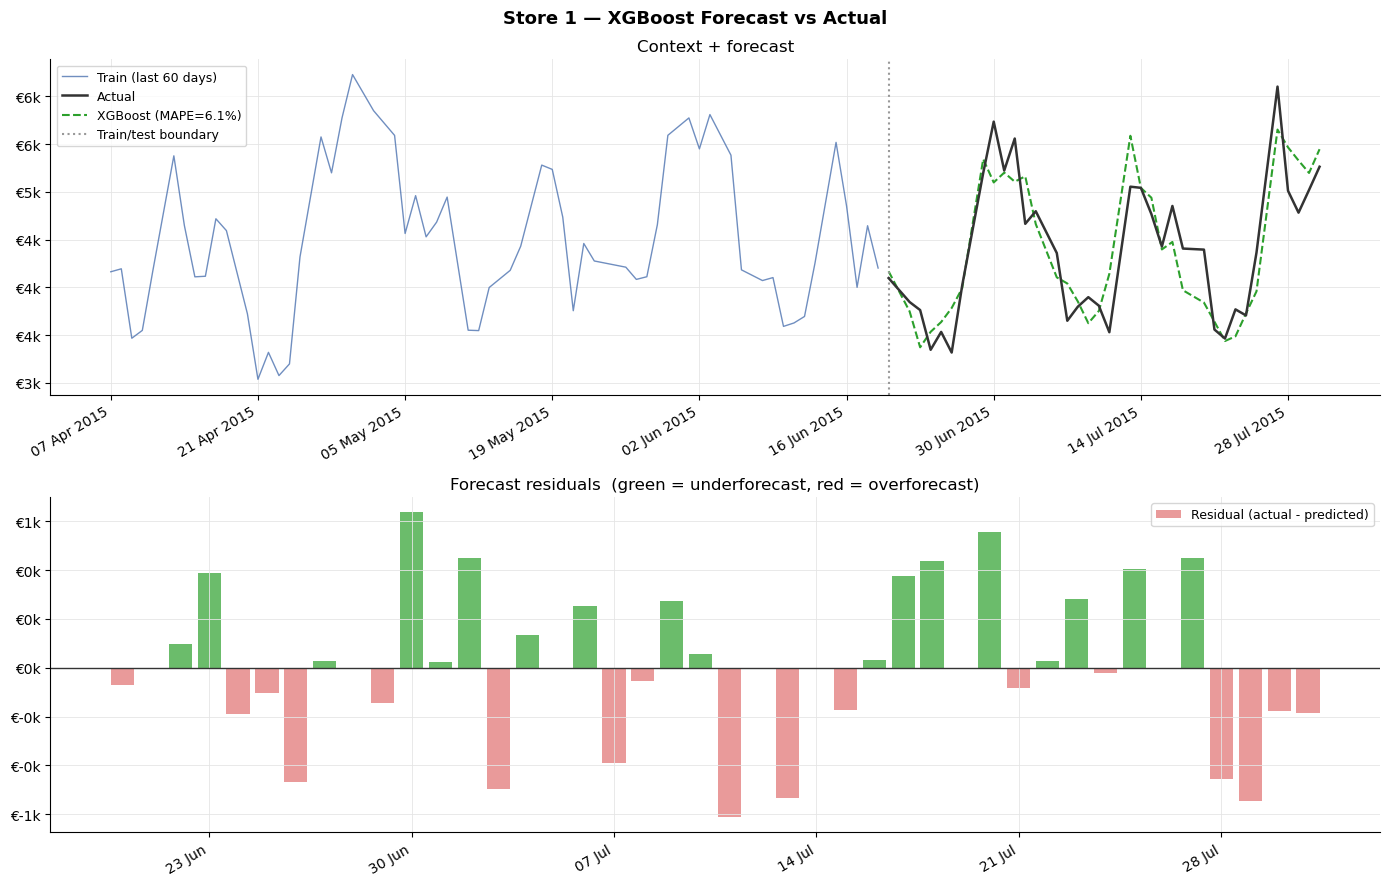

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f"Store {STORE_ID} — XGBoost Forecast vs Actual",
             fontweight="bold", fontsize=13)
 
# Panel 1: Context + forecast
ax = axes[0]
context = train_df.tail(60)
ax.plot(context["Date"], context["Sales"],
        color="#4C72B0", linewidth=1, alpha=0.8, label="Train (last 60 days)")
ax.plot(test_df["Date"], y_test.values,
        color="#333", linewidth=1.8, label="Actual", zorder=5)
ax.plot(test_df["Date"], best_pred,
        color="#2ca02c", linewidth=1.5, linestyle="--",
        label=f"XGBoost (MAPE={best_mape:.1f}%)")
ax.axvline(test_df["Date"].iloc[0], color="#999",
           linestyle=":", linewidth=1.5, label="Train/test boundary")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("Context + forecast")
ax.legend(fontsize=9)
 
# Panel 2: Zoomed in — with residuals
ax2 = axes[1]
residuals = y_test.values - best_pred
ax2.bar(test_df["Date"], residuals,
        color=["#E07070" if r < 0 else "#2ca02c" for r in residuals],
        width=0.8, alpha=0.7, label="Residual (actual - predicted)")
ax2.axhline(0, color="#333", linewidth=1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.set_title("Forecast residuals  (green = underforecast, red = overforecast)")
ax2.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("phase3_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### ALL-STORE EVALUATION

In [15]:
# Show that the model generalises beyond Store 1

 
print("\n── All-store evaluation (sample of 10 stores) ────────")
 
store_sample = df_feat["Store"].unique()[:10]
all_store_results = []
 
for sid in store_sample:
    sdf       = df_feat[df_feat["Store"] == sid]
    spl       = sdf["Date"].max() - pd.Timedelta(weeks=TEST_WEEKS)
    s_train   = sdf[sdf["Date"] <= spl]
    s_test    = sdf[sdf["Date"] >  spl]
 
    if len(s_train) < 50 or len(s_test) < 5:
        continue
 
    xgb_s = XGBRegressor(n_estimators=300, learning_rate=0.05,
                          max_depth=5, random_state=SEED,
                          n_jobs=-1, verbosity=0)
    xgb_s.fit(s_train[FEATURE_COLS], s_train["Sales"], verbose=False)
    s_pred = np.clip(xgb_s.predict(s_test[FEATURE_COLS]), 0, None)
 
    actual = s_test["Sales"].values
    mask   = actual > 0
    mape   = np.mean(np.abs((actual[mask]-s_pred[mask])/actual[mask])) * 100
    all_store_results.append({"Store": sid, "MAPE": round(mape, 2)})
 
all_df = pd.DataFrame(all_store_results)
print(all_df.to_string(index=False))
print(f"\n  Mean MAPE across {len(all_df)} stores: {all_df['MAPE'].mean():.2f}%")


── All-store evaluation (sample of 10 stores) ────────
 Store  MAPE
     1  5.84
     2  8.53
     3  8.35
     4  7.25
     5  8.79
     6  8.68
     7  8.31
     8  7.49
     9 10.19
    10 11.15

  Mean MAPE across 10 stores: 8.46%


### SAVE PREDICTIONS FOR PHASE 4

In [16]:
xgb_preds_df = pd.DataFrame({
    "Date"      : test_df["Date"].values,
    "Actual"    : y_test.values,
    "XGB_pred"  : best_pred,
    "Residual"  : residuals,
})
xgb_preds_df.to_csv("xgb_predictions.csv", index=False)
print(f"\nSaved: xgb_predictions.csv  ← used in Phase 4 comparison")


Saved: xgb_predictions.csv  ← used in Phase 4 comparison
